# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

An area plot is useful because it highlights the combined nitrate and phosphate levels over time and makes overall nutrient load easy to see. However, it can be harder to distinguish individual trends, especially if one nutrient dominates the other or if values overlap. Two separate line graphs make it easier to clearly see and compare individual nitrate and phosphate trends, but they do not emphasize total nutrient impact as effectively. The presentation can be improved by using consistent scales, clear labels and units, distinct colors, and transparency in area plots, or by placing the two line graphs side by side for easier comparison.

In [9]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

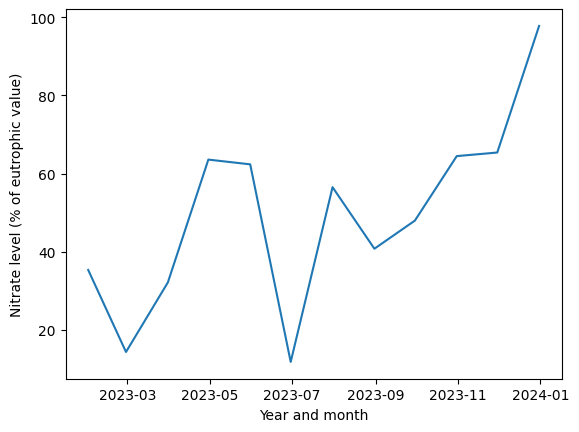

In [10]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

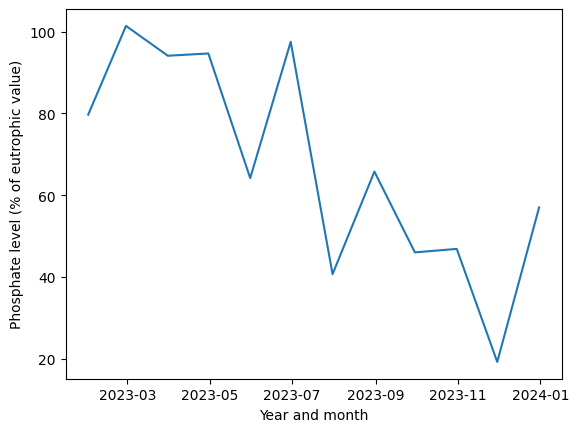

In [11]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

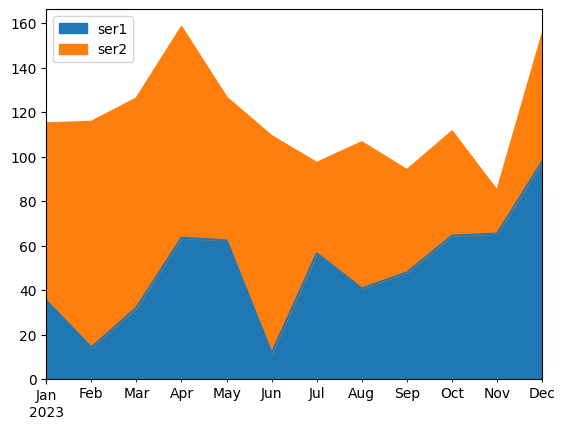

In [12]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)


Dataset loaded successfully!
Dataset shape: (1048575, 11)

Columns: Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

First 5 rows:
    step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0     

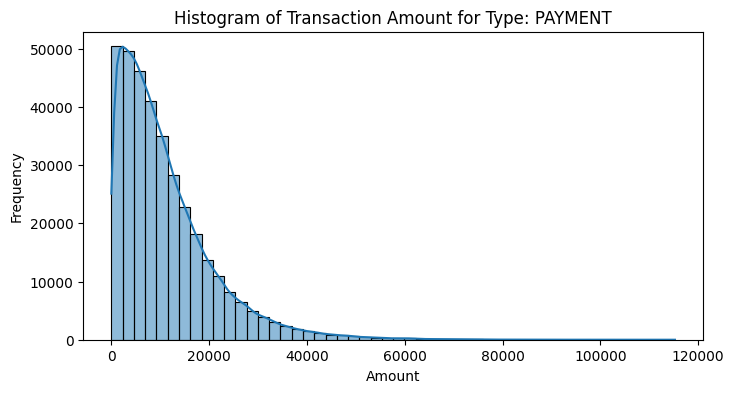

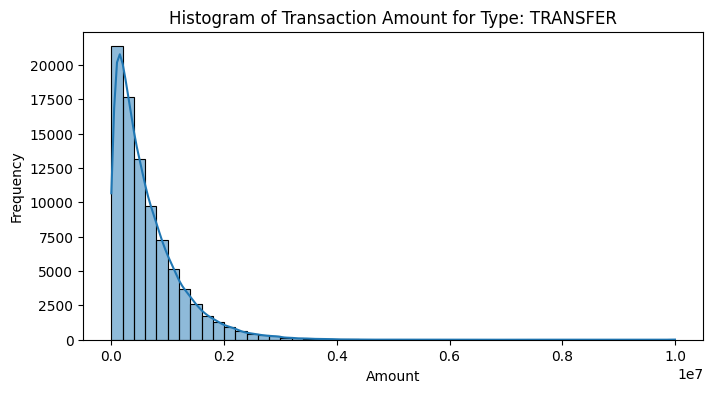

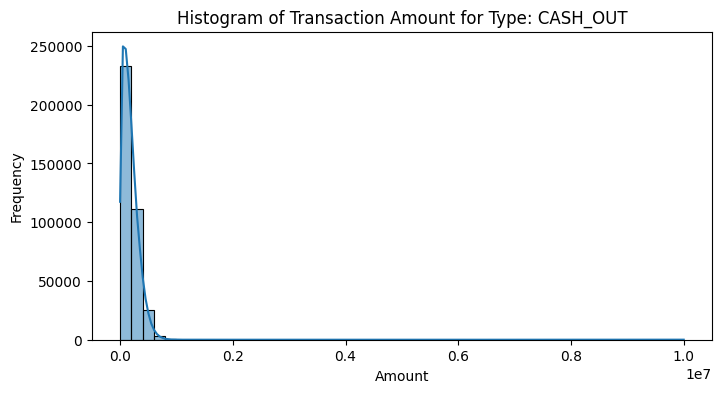

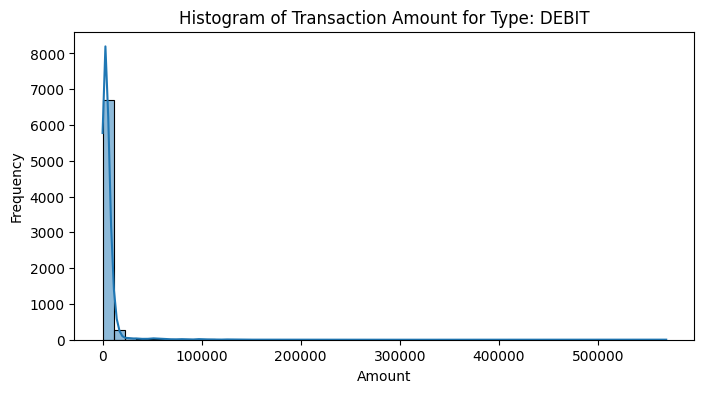

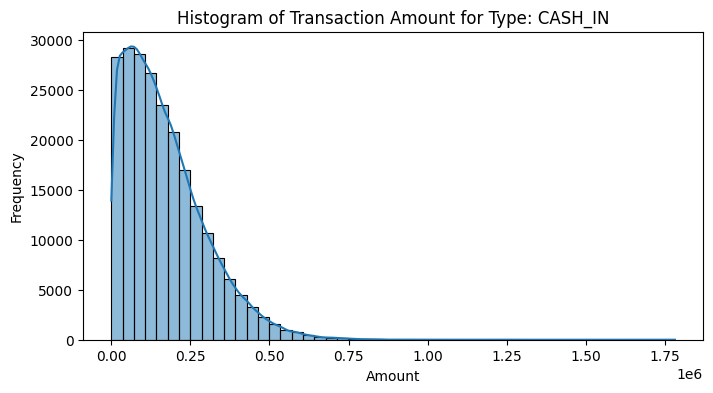

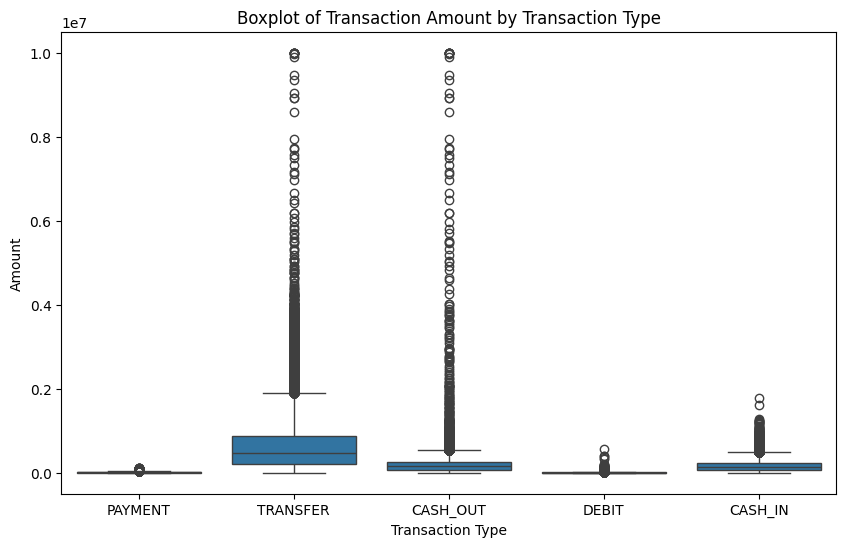

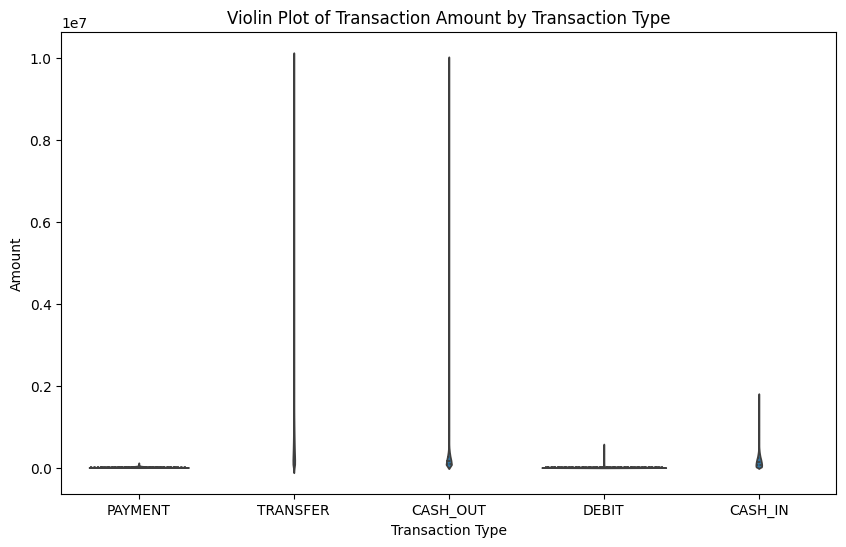

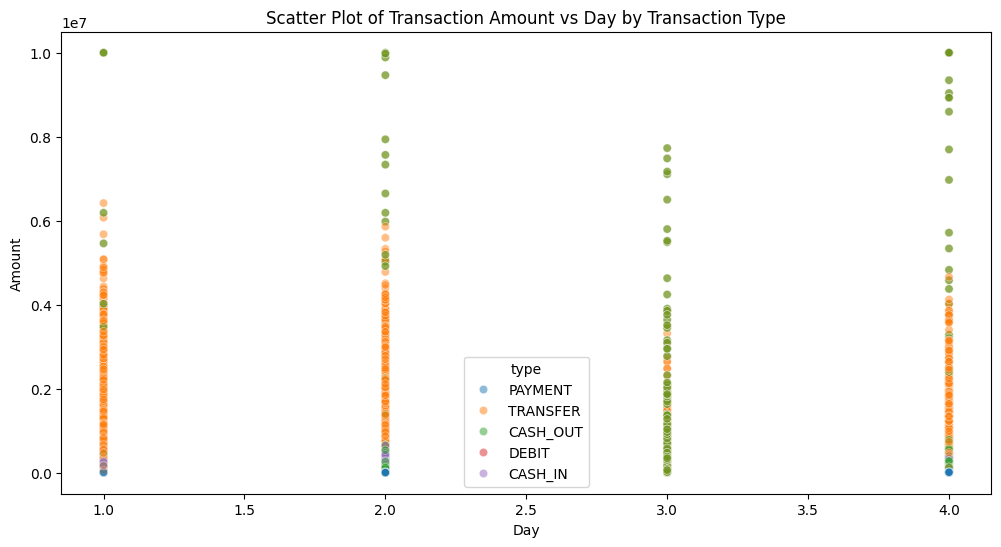

In [13]:
# Bivariate Analysis: PaySim Dataset

# Problem Statement:
# Using the PaySim dataset, explore how transaction amounts vary by transaction type and by simulated day.
# Compute statistics like mean, median, mode, standard deviation, and variance for each type per day.
# Visualize the relationships using grouped histograms, boxplots, violin plots, and scatter plots.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set CSV path
csv_path = "/Users/aakritisharma/Downloads/Boston University/Semester 2/DX699 O2 AI for Leaders (Spring 26)/PS_20174392719_1491204439457_log.csv"

# Load dataset
try:
    df = pd.read_csv(csv_path)
    print("\nDataset loaded successfully!")
    print("Dataset shape:", df.shape)
    print("\nColumns:", df.columns)
    print("\nFirst 5 rows:\n", df.head())
except FileNotFoundError:
    raise FileNotFoundError(f"File not found at {csv_path}. Move the CSV to this folder or update the path.")
# Create 'day' column from 'step' (hours / 24 → day number)
df['day'] = (df['step'] // 24) + 1  # Day 1, Day 2, ...

# Preview dataset
print("Dataset Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

# Group by transaction type and day to compute bivariate stats
grouped = df.groupby(['type', 'day'])['amount']

# Compute mean, median, mode
bivariate_stats = grouped.agg(
    mean_amount='mean',
    median_amount='median',
    mode_amount=lambda x: x.mode()[0]  # take first if multiple modes
).reset_index()
print("\nMean, Median, Mode of Transaction Amount per Type per Day (preview):")
print(bivariate_stats.head(10))

# Compute standard deviation and variance
bivariate_std_var = grouped.agg(
    std_amount='std',
    var_amount='var'
).reset_index()
print("\nStandard Deviation and Variance of Transaction Amount per Type per Day (preview):")
print(bivariate_std_var.head(10))

# Visualizations-Storytelling With Data graph

# Grouped Histograms by Transaction Type
for t in df['type'].unique():
    plt.figure(figsize=(8,4))
    subset = df[df['type'] == t]
    sns.histplot(subset['amount'], bins=50, kde=True)
    plt.title(f"Histogram of Transaction Amount for Type: {t}")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    plt.show()

# Boxplots of Amount by Transaction Type
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='amount', data=df)
plt.title("Boxplot of Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.show()

# Violin Plots of Amount by Transaction Type
plt.figure(figsize=(10,6))
sns.violinplot(x='type', y='amount', data=df, inner='quartile')
plt.title("Violin Plot of Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.show()

# Scatter Plot: Amount vs Day, colored by Transaction Type
plt.figure(figsize=(12,6))
sns.scatterplot(x='day', y='amount', hue='type', data=df, alpha=0.5)
plt.title("Scatter Plot of Transaction Amount vs Day by Transaction Type")
plt.xlabel("Day")
plt.ylabel("Amount")
plt.show()



# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

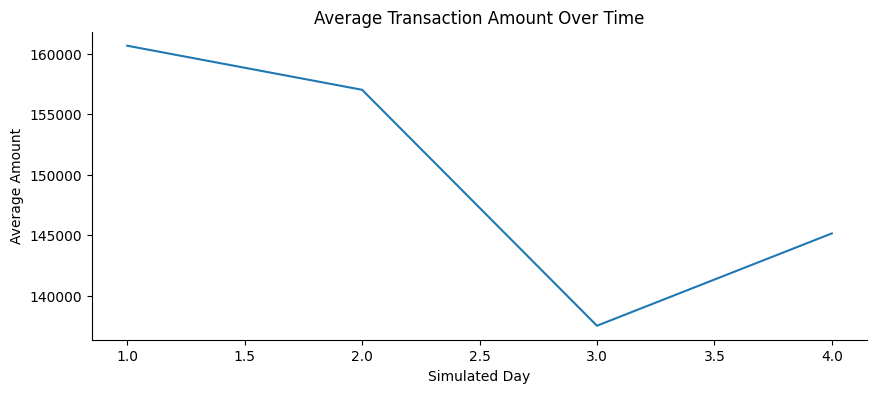

In [15]:
df['day'] = (df['step'] // 24) + 1
daily_avg = df.groupby('day')['amount'].mean()

plt.figure(figsize=(10,4))
ax = sns.lineplot(x=daily_avg.index, y=daily_avg.values)

ax.set_title("Average Transaction Amount Over Time")
ax.set_xlabel("Simulated Day")
ax.set_ylabel("Average Amount")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

# Bivariate Analysis Conclusions – PaySim Dataset

From the bivariate analysis of the PaySim dataset, several conclusions can be drawn.

Overall, the data behave as expected for simulated financial transaction data. Transaction amounts vary significantly by transaction type and show realistic patterns, such as higher amounts for transfers and cash-out transactions compared to payments. This suggests the dataset is usable for exploratory analysis and modeling.

Outliers are clearly present in the transaction amount distributions, particularly for transfer and cash-out transaction types. These outliers represent very large transactions and appear to be meaningful rather than data errors, especially in the context of fraud detection.

Several variables show strong relationships. Transaction amount is highly dependent on transaction type, indicating that transaction type and amount are not independent. This suggests some redundancy, as knowing the transaction type provides substantial information about expected transaction size.

The scatter plot of transaction amount versus simulated day does not show a strong upward or downward trend over time. High-value transactions occur throughout the simulation period rather than increasing or decreasing consistently, suggesting no clear temporal drift that would invalidate comparisons across days.

Potential confounding variables may include account balance, transaction origin or destination, and whether a transaction is fraudulent. These unobserved or indirectly related variables could help explain why certain transaction types consistently show higher amounts or variability.

In summary, the bivariate analysis reveals meaningful relationships between transaction amount, transaction type, and time. The dataset appears realistic, informative, and suitable for further analysis such as fraud detection or behavioral modeling.